### Group Members:

- Damjan Kuzmanovic, 20-743-472 
- Benjamin Donick, 25-723-511
- Name, matriculation number

# Assignment 2: Binary and Categorical Classification

For this assignment, we will use a similar two-layer network as Assignment 1 to implement binary and categorical classification using only `NumPy` package, without relying on `PyTorch` or any deep learning libraries.

We will implement Binary Cross Entropy Loss and Categorical Cross Entropy Loss and their gradient manually with efficient matrix computation, and evaluate accuracy for two classification tasks.  


## Theoretical Questions

We will build and train a two-layer network similar to Assignment 1.
Besides, we will apply **Logistic Function** ($\sigma$) on the logits for binary classification and **Stable Softmax Function** ($\tilde{\mathcal S}$) on the logits for categorical classification.

Questions in this section concern:

1. Comparison between normal softmax $\mathcal S$ and stable softmax $\tilde{\mathcal S}$
2. Compute derivative of $\tilde{\mathcal S}$ that should be applied in the coding section
3. Weight/Parameter Initialization
4. Discussion on Evaluation Metrics of classification tasks

### Task 1.1 Proof of Stable Softmax

The softmax function is defined as:

$$
\mathcal S(z_o) = \frac{e^{z_o}}{\sum\limits_{o'} e^{z_{o'}}}
$$

However, when $ z_o $ has large values, the exponential $ e^{z_o} $ may grow too large, leading to numerical instability (e.g., overflow issues).
To improve stability, we introduce the **stable softmax**:

$$
\tilde{\mathcal S}(z_o) = \frac{e^{z_o - z_{\max}}}{\sum\limits_{o'} e^{z_{o'} - z_{\max}}}
$$

where $z_{\max} = \max\limits_o z_o$.

Prove that stable softmax is mathematically equivalent to the original softmax function.

Discuss how stable softmax improves numerical stability, for instance, what will happen when $z_o$ is too large, or too small?

Answer:

$$\begin{aligned}
\tilde{\mathcal S}(z_o) &= \frac{e^{z_o - z_{\max}}}{\sum\limits_{o'} e^{z_{o'} - z_{\max}}}\\[6ex] 
&= \frac{e^{z_o}e^{-z_{\max}}}{e^{-z_{\max}}\sum\limits_{o'} e^{z_{o'}}} \\[6ex] 
&= \frac{e^{z_o}} {\sum\limits_{o'} e^{z_{o'}}} = \mathcal S(z_o)
\end{aligned}$$

**Prevents Overflow**: If $ z_o $ is large, $ e^{z_o} $ can exceed the floating-point limit, leading to numerical overflow. The stable form ensures all exponentiated terms remain within a reasonable range.

**Prevents Underflow**: If $ z_o $ is very small, $ e^{z_o} $ may be rounded to zero, causing division by a near-zero denominator. Stability ensures a well-defined denominator.


### Task 1.2 Derivative of Stable Softmax


Recall that in the lecture slides, when we compute gradient with respect to $w_{k,d}^{(1)}$ and $w_{o,k}^{(2)}$, as part of the chain rule, we replace $\frac{\partial\mathcal J^{[n]}}{\partial\mathcal y_o^{[n]}}\frac{\partial\mathcal y_o^{[n]}}{\partial\mathcal z_o^{[n]}}$ by $\frac{\partial\mathcal J^{[n]}}{\partial\mathcal z_o^{[n]}}$ when we choose a good activation function.

When normal softmax is applied, we have $\frac{\partial\mathcal J^{[n]}}{\partial\mathcal z_o^{[n]}} = y_o^{[n]} - t_o^{[n]}$. Prove that $\frac{\partial\mathcal J^{[n]}}{\partial\mathcal z_o^{[n]}}$ will return the same format when the activation function is stable softmax.



Answer:

$$\begin{aligned}
\mathcal J^{\text{CCE}}
&= -\frac{1}{N} \sum_{n=1}^{N} \log y_{\tau^{[n]}}^{[n]}
&= -\frac{1}{N} \sum_{n=1}^{N} \log \frac{e^{z_{\tau^{[n]}}^{[n]} - z_{\max}^{[n]}}}{\sum_{o=1}^{O} e^{z_o^{[n]} - z_{\max}^{[n]}}}  
&= -\frac{1}{N} \sum_{n=1}^{N} \log \frac{\sum_{o=1}^{O} t_o^{[n]} e^{z_o^{[n]} - z_{\max}^{[n]}}}{\sum_{o=1}^{O} e^{z_o^{[n]} - z_{\max}^{[n]}}}  \\[6ex]
\end{aligned}$$

$$\begin{aligned}
\frac{\partial\mathcal J^{[n]}}{\partial\mathcal z_o^{[n]}}
&= -\frac{\partial \Bigl[ \sum_{o'=1}^{O} t_{o'}^{[n]}({z_{o'}^{[n]} - z_{\max}^{[n]}}) - \log \sum_{o'=1}^{O} e^{{z_{o'}^{[n]} - z_{\max}^{[n]}}}\Bigr]}{\partial z_o^{[n]}}\\[6ex]
\text{(sum rule)} &= -\frac{\partial \sum_{o'=1}^{O} t_{o'}^{[n]}({z_{o'}^{[n]} - z_{\max}^{[n]}})}{\partial z_o^{[n]}} + \frac{\partial \log \sum_{o'=1}^{O} e^{{z_{o'}^{[n]} - z_{\max}^{[n]}}}}{\partial z_o^{[n]}}\\[6ex]
\text{(sum rule \& logarithm rule)} &=-\frac{\partial t_o^{[n]}({z_o^{[n]} - z_{\max}^{[n]}})}{\partial z_o^{[n]}} + \frac{1}{\sum_{o'=1}^{O} e^{{z_{o'}^{[n]} - z_{\max}^{[n]}}}}\frac{\partial \sum_{o'=1}^{O} e^{{z_{o'}^{[n]}-z_{\max}^{[n]}}}}{\partial z_o^{[n]}}\\[6ex]
\text{(linear/constant \& sum rule)} &= -t_o^{[n]} + \frac{e^{z_o^{[n]}-z_{\max}^{[n]}}}{\sum_{o'=1}^{O} e^{{z_{o'}^{[n]} - z_{\max}^{[n]}}}}
= y_o^{[n]} -t_o^{[n]} 
\end{aligned}$$

### Task 1.3 Weight Initialization

Why do we need to randomly initialize the weights before training starts?

1. Proof that a network with constantly initialized weights perform like a network with one hidden unit.
2. Show that gradient decent is not able to change this behavior and will keep all neurons in the hidden layer identical throughout training.

Answer:

Assume: all weights are initialized identically:

$$\forall d,k \colon w_{k,d}^{(1)} = w_k^{(2)} =  w$$

When we compute the activation $a_k$:

$$a_k = \sum\limits_{d=0}^D w_{k,d}^{(1)} x_d = w \sum\limits_{d=0}^D x_d$$

Thus, the right-hand side is independent of $k$.
Since all activations are identical, the network acts like a single hidden unit.

Also all $h_k = g(a_k) = h$ are identical.

---


Does the weight update improve this behavior?
Let's have a look at the derivatives:
$$\frac{\partial \mathcal J}{\partial w_{k,d}^{(1)}}=\frac{2}{N}\sum_{n=1}^{N}(y^{[n]}-t^{[n]})w_k^{(2)}h_k^{[n]}(1-h_k^{[n]})x_d^{[n]}=\frac{2}{N}\sum_{n=1}^{N}(y^{[n]}-t^{[n]})wh^{[n]}(1-h^{[n]})x_d^{[n]}$$


Again the final formula is independent of $k$.
Thus, the weight updates for all hidden neurons are identical.
Still all weights are identical and it acts like a single hidden unit.


### Task 1.4 Evaluation Metrics

If a binary classifier achieves an accuracy greater than 90%, does this always indicate good performance? Might high accuracy in this binary classification be misleading? 

What alternative evaluation approaches could better capture model performance in such scenarios?


Answer:

In highly unbalanced data, looking at only accuracy is not a good way to capture the model performance. Also, when the context of the problem (churn) is considered, companies does not want their customer to churn. So, they are more interested in people who stop using their products. To evaluate that, it would be better to include another evaluation metric like TPR.

## Coding

**<font color='red' size='5'>This section has to be submitted by 11:59 p.m. on Wednesday, March 25, to be graded.</font>**

### Dataset

We will use two different datasets, the *churn* dataset https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset for a binary classification and the *winequality-red* dataset https://archive.ics.uci.edu/dataset/186/wine+quality for a categorical classification. Both datasets are available on the UCI Machine Learning repository.

The binary classification dataset contains features extracted from customers of a telecommunication company, which are classified as either churn or not.
The categorical classification dataset contains chemical measurements for seven distinct qualities of a Portuguese white wine.
In the former dataset, the class is indicated in the final column named "Churn", whereas for the latter, target information is provided in the last column named "quality."

Please run the code block below to download the data files.

In [3]:
import os
import zipfile
import urllib.request

# Download the two dataset files
dataset_files = {
    "churn_data.zip": "https://archive.ics.uci.edu/static/public/563/iranian+churn+dataset.zip",
    "winequality-red.csv": "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
}

for name, url in dataset_files.items():
    base, extension = os.path.splitext(name)  # Get file name without extension

    if os.path.exists(name):
        print(f"File '{name}' already exists. Skipping download.")
    else:
        # Download the file
        urllib.request.urlretrieve(url, name)
        print(f"Downloaded {name} successfully.")

    # Check if it's a zip file and if it has been extracted
    if extension == ".zip":
        extracted_file = os.path.join(base + ".csv")  # Expected extracted file name

        if not os.path.exists(extracted_file):
            with zipfile.ZipFile(name, 'r') as zip_ref:
                zip_ref.extractall()
            print(f"Extracted {name} successfully.")

            # Rename the extracted file
            os.rename("Customer Churn.csv", extracted_file)
        else:
            print(f"File '{extracted_file}' already extracted. Skipping extraction.")


File 'churn_data.zip' already exists. Skipping download.
File 'churn_data.csv' already extracted. Skipping extraction.
File 'winequality-red.csv' already exists. Skipping download.


#### Task 2.1: Dataset Loading

The first task deals with the loading of the datasets.
When training networks in `NumPy`, all data needs to be stored as NumPy arrays.
The data should be split between input matrix $\mathbf X \in \mathbb R^{D\times N}$ and target matrix $\mathbf T \in \mathbb R^{O\times N}$.
We need to **add a bias neuron to the input** so that we have $\mathbf X \in \mathbb R^{(D+1)\times N}$


<!-- For the targets, we have to be more careful as there are differences w.r.t. the applied loss function.

*   For binary classification, we need $\mathbf T \in \mathbb R^{1\times N}$.
*   For categorical classification, we only need the class indexes $\vec t = [t^{[1]}, \ldots, t^{[N]}]$ to be in dimension $\mathbb N^N$. -->


Implement a function that returns both the input and the target data for a given dataset.

Note:

1. You can use `csv.reader()` to read the dataset, or rely on other methods such as `pandas`
2. Please note that in the wine dataset CSV file, all values are separated by `;`, whereas in the churn dataset, they are separated by `,`
3. For the wine dataset, convert 6 target values into a one-hot matrix so that the dimension is $\mathbb R^{6\times N}$. **Be aware that the target values in the wine dataset do not start at index 0.**

In [4]:
import numpy
import csv

def dataset(dataset_file="winequality-red.csv",delimiter=";"):
    """
    Load a dataset from a CSV file and return the input and target matrices.

    Args:
    dataset_file: Path to the dataset CSV file.
    delimiter: Delimiter used in the CSV file.
    Returns:
        X: Input matrix (D+1, N) including bias neuron.
        T: Target matrix. One-hot encoded for the wine dataset or float values for other datasets.
    """
    # read dataset
    data = []
    with open(dataset_file, 'r') as f:
      reader = csv.reader(f,delimiter=delimiter)
      next(reader)
      for row in reader:
         data.append([float(x) for x in row]) 

    print (f"Loaded dataset with {len(data)} samples")

    # Convert to NumPy array
    data = numpy.array(data) 

    # Get the input (data samples)
    X = data[:, :-1]
    # Insert bias neuron (add a column of ones) to the input
    X = X.T
    X = numpy.vstack([numpy.ones((1, X.shape[1])), X])

    if dataset_file == "winequality-red.csv":
      # target is in the last column and needs to be converted into one-hot format
      targets = data[:,-1].astype(int)
      targets = targets - targets.min() #shift to 0-indexed
      T = numpy.eye(targets.max()+1)[targets].T
    else:
      # target is in the last column and needs to be of type float
      T = data[:,-1].reshape(1,-1).astype(numpy.float64)

    return X, T

#### Test 1: Assert Valid Outputs


1. For the churn data, we assure that all dimensions are correct and that class labels are in $\{0, 1\}$.

2. For the wine dataset, we make sure that the dataset is in the correct dimensions, i.e., $\mathbf X\in \mathbb R^{(D+1)\times N}$ and $\mathbf T \in \mathbb N^{O\times N}$. We verify that each sample in $\mathbf T$ has exactly one active class (one-hot encoding).

In [5]:
# Load datasets using the dataset function
X, T = dataset("churn_data.csv", ",")

# Assert checks for the churn dataset
assert X.shape[0] == 14, X.shape[0]
assert T.shape[0] == 1, T.shape[0]
assert numpy.all(T >= 0) and numpy.all(T <= 1)
assert T.dtype == numpy.float64

# Load wine dataset
X, T = dataset("winequality-red.csv", ";")

# Assert checks for the winequality-red dataset
assert X.shape[0] == 12, X.shape[0]
assert T.shape[0] == 6, T.shape[0]
# assert numpy.all(T >= 0) and numpy.all(T <= 1)
assert numpy.all(numpy.sum(T, axis=0) == 1), "Error: Some samples are not correctly one-hot encoded!" # ensures that each column sums to exactly 1
assert T.dtype == numpy.float64

Loaded dataset with 3150 samples
Loaded dataset with 1599 samples


#### Task 2.2: Split Training and Validation Data


The data should be split into 80% for training and 20% for validation. Implement a function that takes the full dataset $(X,T)$ and returns $(X_t, T_t, X_v, T_v)$ accordingly.

Write a function that splits off training and validation samples from a given dataset. **What do we need to assure before splitting?**


In [6]:
def split_training_data(X,T,train_percentage=0.8):
    """
    Split the dataset into training and validation sets.

    Args:
        X: Input matrix (D+1, N) including bias.
        T: Target matrix (O, N).
        train_percentage: Fraction of samples used for training.

    Returns:
        X_train: Training input matrix.
        T_train: Training target matrix.
        X_val: Validation input matrix.
        T_val: Validation target matrix.
    """
    N = X.shape[1]

    indices = numpy.random.permutation(N)
    X = X[:, indices]
    T = T[:, indices] # Rendomly permute the columns first to avoid clustering od the classes

    # split into 80/20 training/validation
    split = int(N*train_percentage)
    X_train = X[:, :split]
    T_train = T[:, :split]
    X_val = X[:, split:]
    T_val = T[:, split:]

    return X_train, T_train, X_val, T_val

#### Task 2.3: Input Data Normalization


Since the data is in different input regimes, we want to normalize the data.

Implement a function that normalizes all input data using the whitening method with given mean and standard deviation.
$$X_{norm} = \frac{X-\mu}{\sigma}$$
Compute the mean ($\mu$) and the standard deviation ($\sigma$) for your dataset.
Make sure that you handle the bias neuron $x_0$ correctly.
Finally, normalize your input data using the implemented function.

Note: Use `numpy.mean()` and `numpy.std()` with the correct dimensions.

In [7]:
def normalize(X_train, X_val):
    """
    Normalize the training and validation input data using standardization.

    Args:
        X_train: Training input matrix (D+1, N_train) including bias.
        X_val: Validation input matrix (D+1, N_val) including bias.

    Returns:
        X_train_normalize: Normalized training input matrix.
        X_val_normalize: Normalized validation input matrix.
    """
    # Compute statistics
    mean = numpy.mean(X_train, axis=1, keepdims=True)
    std = numpy.std(X_train, axis=1, keepdims=True)

    # Ensure that the bias neuron is not normalized
    mean[0] = 0
    std[0] = 1

    # Standardize both X_train and X_val
    X_train_normalize = (X_train-mean)/std
    X_val_normalize = (X_val-mean)/std

    return X_train_normalize, X_val_normalize

### Gradient Descent

To train a two-layer multi-output regression network, we need to implement some functions.
The network output is computed in three steps:

  * Compute network activation for a batch of inputs $\mathbf X$: $\mathbf A = \mathbf W^{(1)}\mathbf X$
  * Call the activation function element-wise: $\mathbf H = g(\mathbf A)$. Here, we rely on the $\tanh$ function. Assure that the hidden neuron bias $\mathbf H_{0,:}$ is set appropriately.
  * Compute the logits $\mathbf Z$ of the batch: $\mathbf Z = \mathbf W^{(2)}\mathbf H$.

#### Task 2.4: Activation of Output

In this task, we will implement the activation functions used in binary and categorical classification:  

1. Logistic Function (for Binary Classification)  
   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$

2. Stable Softmax Function (for Categorical Classification)
  $$
   \tilde{\mathcal S}(z_o) = \frac{e^{z_o - z_{max}}}{\sum\limits_{o'} e^{z_{o'} - z_{max}}}
   $$

In [8]:
def logistic_function(z):
    """
    Compute the logistic sigmoid activation function.

    Args:
        z: Input array containing the linear activations.

    Returns:
        y: Output after applying the sigmoid function.
    """
    val = 1/(1+numpy.exp(-z))
    return val

def stable_softmax(z):
    """
    Compute the softmax activation function in a numerically stable way.

    Args:
        z: Input matrix containing the output logits.

    Returns:
        y: Probability matrix where each column sums to 1.
    """
    z_max = numpy.max(z, axis=0, keepdims=True)
    exp_z = numpy.exp(z-z_max)
    val = exp_z/numpy.sum(exp_z, axis=0, keepdims=True)
    return val 

#### Task 2.5: Network Implementation

Implement a multi-target network that computes the output matrix $\mathbf Y$ for a given input dataset $\mathbf X$ and given parameters $(\mathbf W^{(1)}, \mathbf W^{(2)})$ using `numpy` operations. Use $\tanh$ as activation function between two layers.

The function should return both the output $\mathbf Y$ and the output of the hidden units $\mathbf H$ since we will need these in gradient descent. 
When applying binary cross entropy loss, we apply the logistic function $\sigma$ to the logits $\mathbf Z$ before returning it.
When applying categorical cross entropy loss, we apply stable softmax $\tilde{\mathcal S}$ to the logits $\mathbf Z$ before returning it.

In [9]:
def Network(X, W1, W2, loss_type='bce'):
  """
  Compute the output of a two-layer neural network model.

  Args:
      X: Input matrix (D+1, N) including bias.
      W1: Weight matrix for the hidden layer.
      W2: Weight matrix for the output layer.
      loss_type: Type of loss function used ('bce' or 'cce').

  Returns:
      Y: Network output predictions.
      H: Hidden layer output including bias neuron.
  """

  # compute activation
  A = numpy.dot(W1,X)

  # compute hidden unit output
  H = numpy.vstack([numpy.ones((1, X.shape[1])), numpy.tanh(A)])

  Z=numpy.dot(W2,H)

  # compute network output
  if loss_type == 'bce':
    Y = logistic_function(Z)
  else:
    Y= stable_softmax(Z)

  return Y, H

#### Task 2.6: Loss Implementation

Implement a loss function that returns the Binary Cross-Entropy (BCE) loss for binary classification and the Categorical Cross-Entropy (CCE) loss for categorical classification.
Note that for BCE, $O=1$ so that both $\mathbf Y\in\mathbb R^{O\times N}$ and $\mathbf T\in\mathbb N^{O\times N}$ are considered as vectors.

$$
\mathcal J^{\mathrm{BCE}} = -\frac{1}{N} \left[ \mathbf T \odot \log \mathbf Y + (1 - \mathbf T) \odot \log (1 - \mathbf Y) \right] \vec{\mathbf 1}_N
$$

$$
\mathcal J^{\mathrm{CCE}} = -\frac{1}{N} \vec{\mathbf 1}_O^T [\mathbf T \odot \log \mathbf Y] \vec{\mathbf 1}_N
$$

where $\odot$ represents the element-wise multiplication, and $\vec{\mathbf 1}_N$ a vector containing $N$ ones.
For both losses, the mathematical expressions above can be implemented much easier, by using basic `numpy` or `scipy` functionality.

In [10]:
def loss(Y, T, loss_type):
  """
  Compute the loss between predictions and targets.

  Args:
    Y: Predicted output probabilities from the network.
    T: Target matrix.
    loss_type: Type of loss function ('bce' or 'cce').

  Returns:
    L: Computed loss value.
  """

  N = Y.shape[1]
  if loss_type == 'bce':
    L = -numpy.sum(T * numpy.log(Y) + (1 - T) * numpy.log(1 - Y)) / N
  else:
    L = -numpy.sum(T * numpy.log(Y)) / N


  return L

#### Task 2.7: Gradient Implementation

Implement a function that computes and returns the gradient for a given batch $(\mathbf X, \mathbf T)$, the given network outputs $\mathbf Y$ and $\mathbf H$ as well as current parameters $(\mathbf W^{(1)}, \mathbf W^{(2)})$.
Make sure to compute the gradient with respect to both weight matrices. Remember that we have used `tanh` as the activation function between two layers.
Implement the function using the fast version provided in the lecture and make use of `numpy` operations.

In [11]:
def gradient(X, T, Y, H, W1, W2):
  """
  Compute the gradients of the loss with respect to the network weights.

  Args:
      X: Input matrix (D+1, N) including bias.
      T: Target matrix.
      Y: Predicted output from the network.
      H: Hidden layer output including bias neuron.
      W1: Weight matrix for the hidden layer.
      W2: Weight matrix for the output layer.

  Returns:
      g1: Gradient with respect to W1.
      g2: Gradient with respect to W2.
  """

  # Derivative with respect to W2
  N = X.shape[1]
  g2 = (Y - T) @ H.T / N

  # Compute the derivative with respect to W1
  delta = numpy.dot(W2.T,(Y-T))
  delta = delta[1:, :] * (1 - H[1:, :] ** 2)
  g1 = numpy.dot(delta, X.T)/N

  return g1, g2


#### Task 2.8: Accuracy Computation


Implement a function that computes the accuracy of the provided network output and the given target values.
Make sure that the implementation supports both binary as well as categorical targets.

In [12]:
def accuracy(Y, T):
  """
  Compute the classification accuracy.

  Args:
    Y: Predicted output probabilities from the network.
    T: Target matrix.

  Returns:
    acc: Classification accuracy.
  """
  # check if we have binary or categorical classification
  if T.shape[0]==1:
    # binary classification
    predictions = (Y>0.5).astype(int)
    return numpy.mean(predictions == T)
  else:
    # categorical classification
    pred_classes = numpy.argmax(Y, axis=0)
    true_classes = numpy.argmax(T, axis=0)
    return numpy.mean(pred_classes == true_classes)

#### Test 2: Test Accuracy Function


Design test data and according logit values with which you can test the correctness of your accuracy function.
Make sure that the accuracy will compute the correct values.
Test both binary and categorical accuracy.

In [13]:
# first, test binary classification
YY = numpy.ones((1,20)) * -5.
YY[0][15:20] = 5
assert(abs(accuracy(YY,numpy.zeros((1,20))) - 0.75) < 1e-8)
assert(abs(accuracy(YY,numpy.ones((1,20))) - 0.25) < 1e-8)

# now, test categorical classification with 4 classes
YY = numpy.ones((4, 20)) * -5  # Shape (C, N) to match function expectations
YY[0, 0:1] = 5
YY[1, 1:4] = 5
YY[2, 4:10] = 5
YY[3, 10:20] = 5
# Modify YY and T to be one-hot encoded
T0 = numpy.eye(4)[numpy.zeros(20, dtype=int)].T
T1 = numpy.eye(4)[numpy.ones(20, dtype=int)].T
T2 = numpy.eye(4)[numpy.ones(20, dtype=int) * 2].T
T3 = numpy.eye(4)[numpy.ones(20, dtype=int) * 3].T
T4 = numpy.eye(4)[numpy.array([0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])].T

# Assertions with modified inputs
assert abs(accuracy(YY, T0) - 0.05) < 1e-8
assert abs(accuracy(YY, T1) - 0.15) < 1e-8
assert abs(accuracy(YY, T2) - 0.3) < 1e-8
assert abs(accuracy(YY, T3) - 0.5) < 1e-8
assert abs(accuracy(YY, T4) - 1.0) < 1e-8

#### Task 2.9: Training Loop


Implement gradient descent for a given number of 10'000 epochs using given input data, initial parameters $(\mathbf W^{(1)}, \mathbf W^{(2)})$, loss_type, number of epochs, as well as a learning rate of $\eta=0.1$.

Make use of the normalized dataset from Task 2.3, the network from Task 2.5, the loss from Task 2.6, the gradient from Task 2.7, and the accuracy function from Task 2.8.

Make sure that you train on the training data only, and not on the validation data.
In each loop, compute and store the training loss, training accuracy, validation loss and validation accuracy.
At the end, return the lists of these values.


In [14]:
def train(X_train, T_train, X_val, T_val, W1, W2, epochs=10000, eta=0.1, loss_type='bce'):
  """
  Train a two-layer neural network using gradient descent.

  Args:
    ... (to be decided by yourself)

  Returns:
    train_loss: List of training loss values per epoch.
    train_acc: List of training accuracy values per epoch.
    val_loss: List of validation loss values per epoch.
    val_acc: List of validation accuracy values per epoch.
  """

  ...

  # collect loss and accuracy values
  train_loss, train_acc, val_loss, val_acc = [], [], [], []

  for epoch in range(epochs):
    # train on training set
    Y_train, H_train = Network(X_train, W1, W2, loss_type)
    # ... compute network output on training data
    ...
    # ... compute loss from network output and target data
    ...
    # ... compute gradient and perform weight update
    g1, g2 = gradient(X_train, T_train, Y_train, H_train, W1, W2)
    W1 = W1 - eta * g1
    W2 = W2 - eta * g2
    # ... remember loss
    train_loss.append(loss(Y_train, T_train, loss_type))
    # ... compute training set accuracy
    train_acc.append(accuracy(Y_train, T_train))

    # test on validation data

    # ... compute network output on validation data
    Y_val, H_val = Network(X_val, W1, W2, loss_type)
    # ... compute loss from network output and target data
    ...
    # ... remember loss
    val_loss.append(loss(Y_val, T_val, loss_type))
    # ... compute validation set accuracy
    val_acc.append(accuracy(Y_val, T_val))

  # return the four lists of losses and accuracies
  return train_loss, train_acc, val_loss, val_acc

#### Task 2.10: Plotting Function


Implement a function that takes four lists containing the training loss, the training accuracy, the validation loss and the validation accuracy.
Plot the two losses into one plot, and the two accuracies into another plot.

In [15]:
from matplotlib import pyplot
def plot(train_loss, train_acc, val_loss, val_acc):
  """
  Plot training and validation loss and accuracy over epochs.

  Args:
    train_loss: List of training loss values per epoch.
    train_acc: List of training accuracy values per epoch.
    val_loss: List of validation loss values per epoch.
    val_acc: List of validation accuracy values per epoch.
  """
  pyplot.figure(figsize=(10,3))
  ax = pyplot.subplot(121)
  ax.plot(train_loss, "g-", label="Training set loss")
  ax.plot(val_loss, "b-", label="Validation set loss")
  ax.set_xlabel("Epoch")
  ax.legend()

  ax = pyplot.subplot(122)
  ax.plot(train_acc, "g-", label="Training set accuracy")
  ax.plot(val_acc, "b-", label="Validation set accuracy")
  ax.set_xlabel("Epoch")
  ax.legend()

#### Task 2.11: Binary Classification


1. Load the data for binary classification, using the ``"churn_data.csv"`` file.
2. Split the data into training and validation sets.
3. Normalize both training and validation input data using the function from Task 2.3.
4. Instantiate the weight matrices $(\mathbf W^{(1)}, \mathbf W^{(2)})$ using the Xavier method as introduced in the lecture
5. Train the network on the churn data with the learning rate of **$\eta=0.1$** for 10'000 epochs and plot the training and validation accuracies and losses.



Loaded dataset with 3150 samples


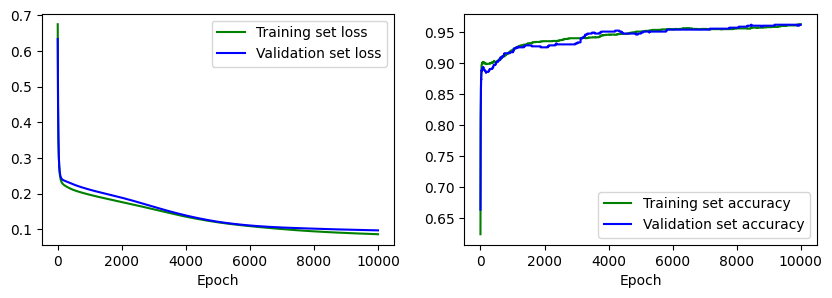

In [16]:
# load dataset
X, T = dataset("churn_data.csv", ",")
# split dataset
X_train, T_train, X_val, T_val = split_training_data(X,T)
# normalize input data
X_train, X_val = normalize(X_train,X_val)

K = 20
D = X_train.shape[0]
O = 1
W1 = numpy.random.randn(K, D) / numpy.sqrt(D)
W2 = numpy.random.randn(O, K + 1) / numpy.sqrt(K + 1)

# train network on our data
results = train(X_train, T_train, X_val, T_val, W1, W2, epochs=10000, eta=0.1, loss_type='bce')

# plot the results
plot(*results)

#### Task 2.12: Categorical Classification


1. Load the data for categorical classification, using the ``"winequality-red.csv"`` file.
2. Split the data into training and validation sets.
3. Normalize both training and validation input data using the function from Task 2.3.
4. **How many input and output neurons do we need?** Change the number of input, hidden, and output neurons accordingly. Select an appropriate number of hidden neurons $K$.
5. Instantiate the weight matrices $(\mathbf W^{(1)}, \mathbf W^{(2)})$ using the Xavier method as introduced in the lecture
6. Train the network on the winequality-red dataset with the learning rate of **$\eta=0.1$** for 10'000 epochs and plot the training and validation accuracies and losses.



Loaded dataset with 1599 samples


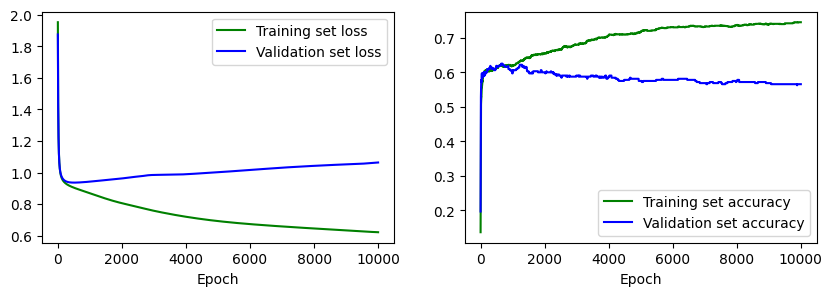

In [17]:

# load dataset
X, T = dataset("winequality-red.csv", ";")
# split dataset
X_train, T_train, X_val, T_val = split_training_data(X, T)
# normalize input data
X_train, X_val = normalize(X_train, X_val)

K = 20
D = X_train.shape[0]
O = T_train.shape[0]
W1 = numpy.random.randn(K, D) / numpy.sqrt(D)
W2 = numpy.random.randn(O, K + 1) / numpy.sqrt(K + 1)

# train network on our data
results = train(X_train, T_train, X_val, T_val, W1, W2, epochs=10000, eta=0.1, loss_type='cce')

# plot the results
plot(*results)